In [2]:
import torch
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from protenix.utils.lmdb import LMDBDataset
from protenix.utils.plottool import init_plot_settings

import matplotlib.pyplot as plt



lmdb = LMDBDataset("/data/rerank/protenix/chembl_bdb/chembl_bdb_meta.lmdb")
assay_groups = lmdb["assay_groups_detail"]
assay_pairs = lmdb["assay_pairs_0.5_1.0"]


print("assay whose protein len < 1024")
assay_below_1024 = {}
for name, assay in assay_groups.items():
    if len(assay) > 0:
        data = lmdb[assay[0]['name']]
        if len(data["sequences"][0]["proteinChain"]["sequence"]) < 1024:
            assay_below_1024[name] = assay
print(f"before filter: {len(assay_groups)}")
print(f"after filter: {len(assay_below_1024)}")


print("30 identity filter")
with open("../scripts/split/splits/chembl_bdb.dude_litpcba_fep.30.json") as f:
    full_data_split_30 = json.load(f)
assay_30_train = {}
assay_30_valid = {}
for name, assay in assay_below_1024.items():
    uniprot_id = name.split("_")[-2]
    if uniprot_id in full_data_split_30["train"]:
        assay_30_train[name] = assay
    elif uniprot_id in full_data_split_30["valid"]:
        assay_30_valid[name] = assay
    else:
        print(f"uniprot id {uniprot_id} not in train or valid")
print(f"train: {len(assay_30_train)}")
print(f"valid: {len(assay_30_valid)}")

assay_pairs_30_train = {}
assay_pairs_30_valid = {}
assay_pairs_filtered = {}
for key in assay_30_train:
    if key in assay_pairs:
        assay_pairs_30_train[key] = assay_pairs[key]
        assay_pairs_filtered[key] = assay_pairs[key]
for key in assay_30_valid:
    if key in assay_pairs:
        assay_pairs_30_valid[key] = assay_pairs[key]
        assay_pairs_filtered[key] = assay_pairs[key]

print("filter out assay without pairs")
print(f"train: {len(assay_pairs_30_train)}")
print(f"valid: {len(assay_pairs_30_valid)}")
print(f"total: {len(assay_pairs_filtered)}")

assay whose protein len < 1024
before filter: 153638
after filter: 125472
30 identity filter
train: 51544
valid: 73928
filter out assay without pairs
train: 25052
valid: 34192
total: 59244


In [3]:
init_plot_settings()

total journal impact factors: 80
max impact factor: 122.8


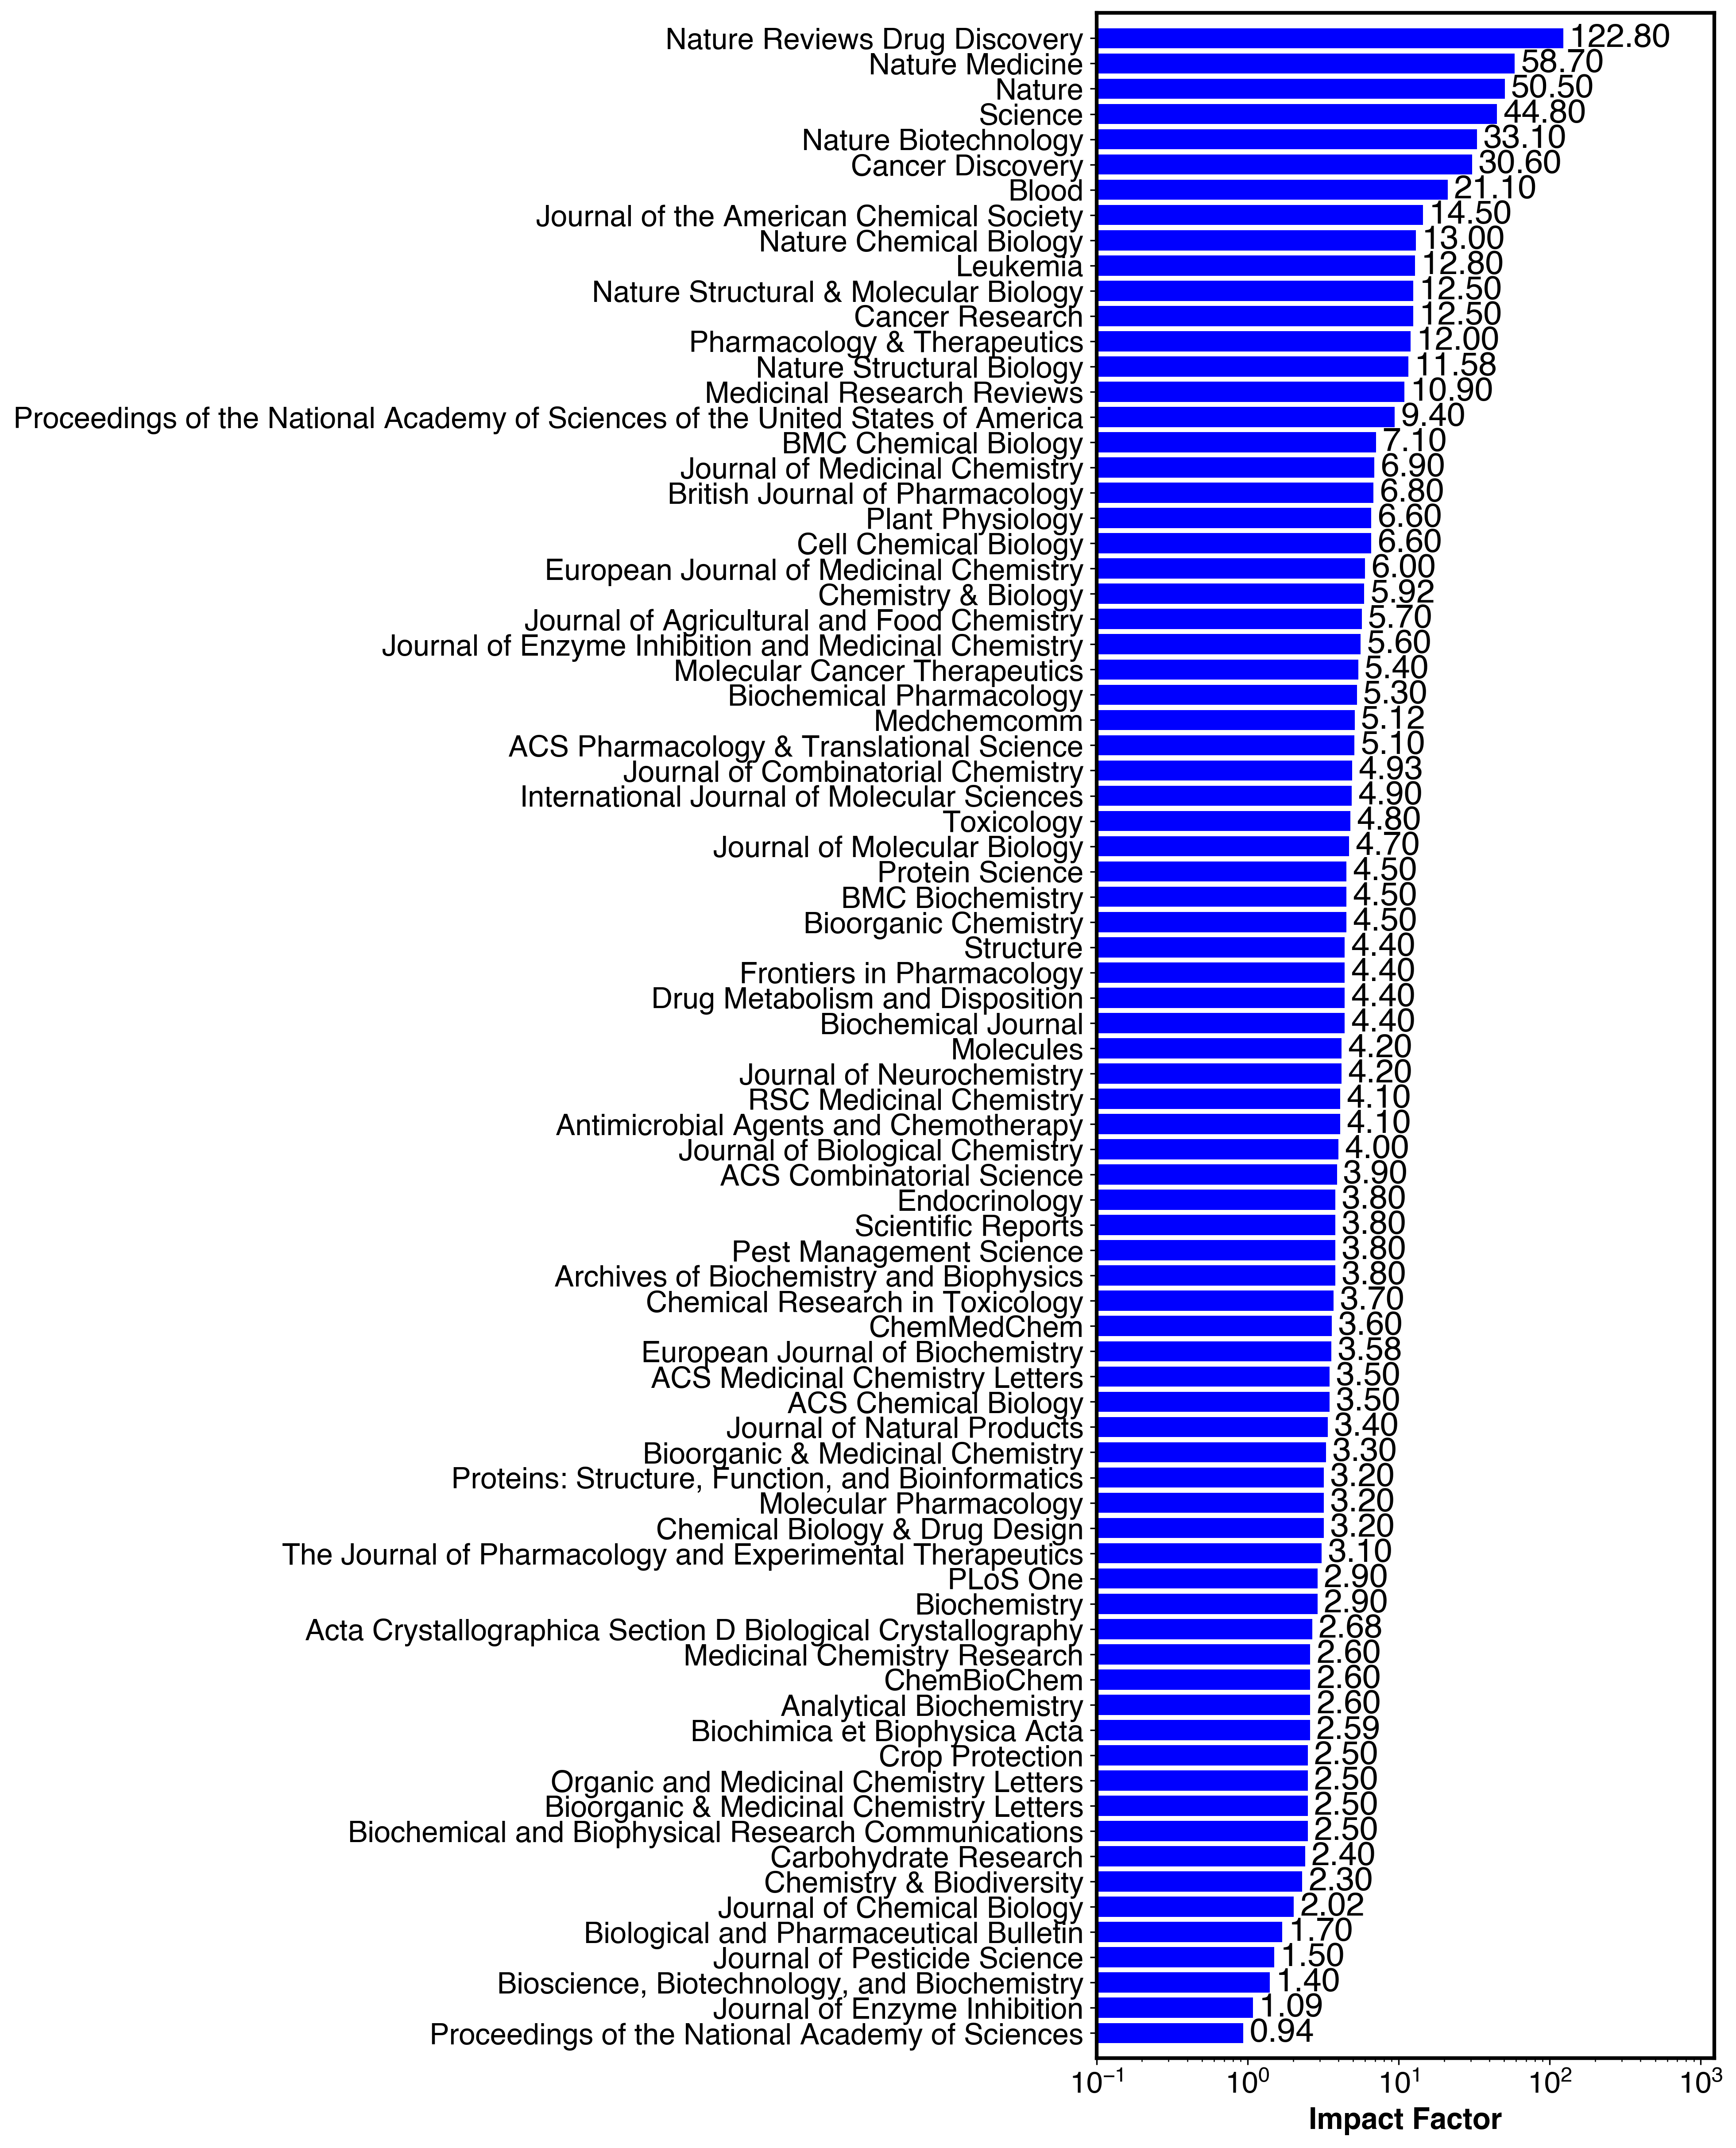

In [4]:
with open("/data/rerank/protenix/chembl_bdb/impact_factor.json") as f:
    impact_factor = json.load(f)
impact_factors = [
    (key, float(value["impact_factor"]))
    for key, value in impact_factor.items()
    if key in impact_factor
]
sorted_impact_factors = sorted(impact_factors, key=lambda x: x[1])
print(f"total journal impact factors: {len(impact_factors)}")
print(f"max impact factor: {max([x[1] for x in impact_factors])}")

impact_factots_mapping = {}
for key, value in impact_factor.items():
    impact_factots_mapping[key] = float(value["impact_factor"])
    for abbr in value["abbreviations"]:
        impact_factots_mapping[abbr.strip("'")] = float(value["impact_factor"])

plt.figure(figsize=(6, 20))
# horizontal bar plot
barplot = plt.barh(
    [x[0] for x in sorted_impact_factors],
    [x[1] for x in sorted_impact_factors],
    color="blue",
)
# plt.xticks(rotation=90)
plt.xscale("log")
plt.ylim(-1, len(sorted_impact_factors))

# add text to the right of each bar
for i, v in enumerate([x[1] for x in sorted_impact_factors]):
    plt.text(
        v * 1.1,
        i,
        f"{v:.2f}",
        color="black",
        va="center",
    )
plt.xlim(0.1, max([x[1] for x in sorted_impact_factors]) * 10)
plt.xlabel("Impact Factor")
plt.show()

In [5]:
unique_journals = set()
for name, assay in assay_pairs_filtered.items():
    if len(assay) > 0:
        data = lmdb[assay[0][0]]
        if "journal" in data:
            unique_journals.add(data["journal"])
print(f"unique journals: {len(unique_journals)}")

unique journals: 85


In [6]:
print("journals not in included:")
for journal in unique_journals:
    if journal not in impact_factots_mapping:
        print(journal)

journals not in included:



assay scoreing


100%|██████████████████████████████████| 59244/59244 [00:01<00:00, 57783.02it/s]


total assay: 59244
journal zero assay: 10961


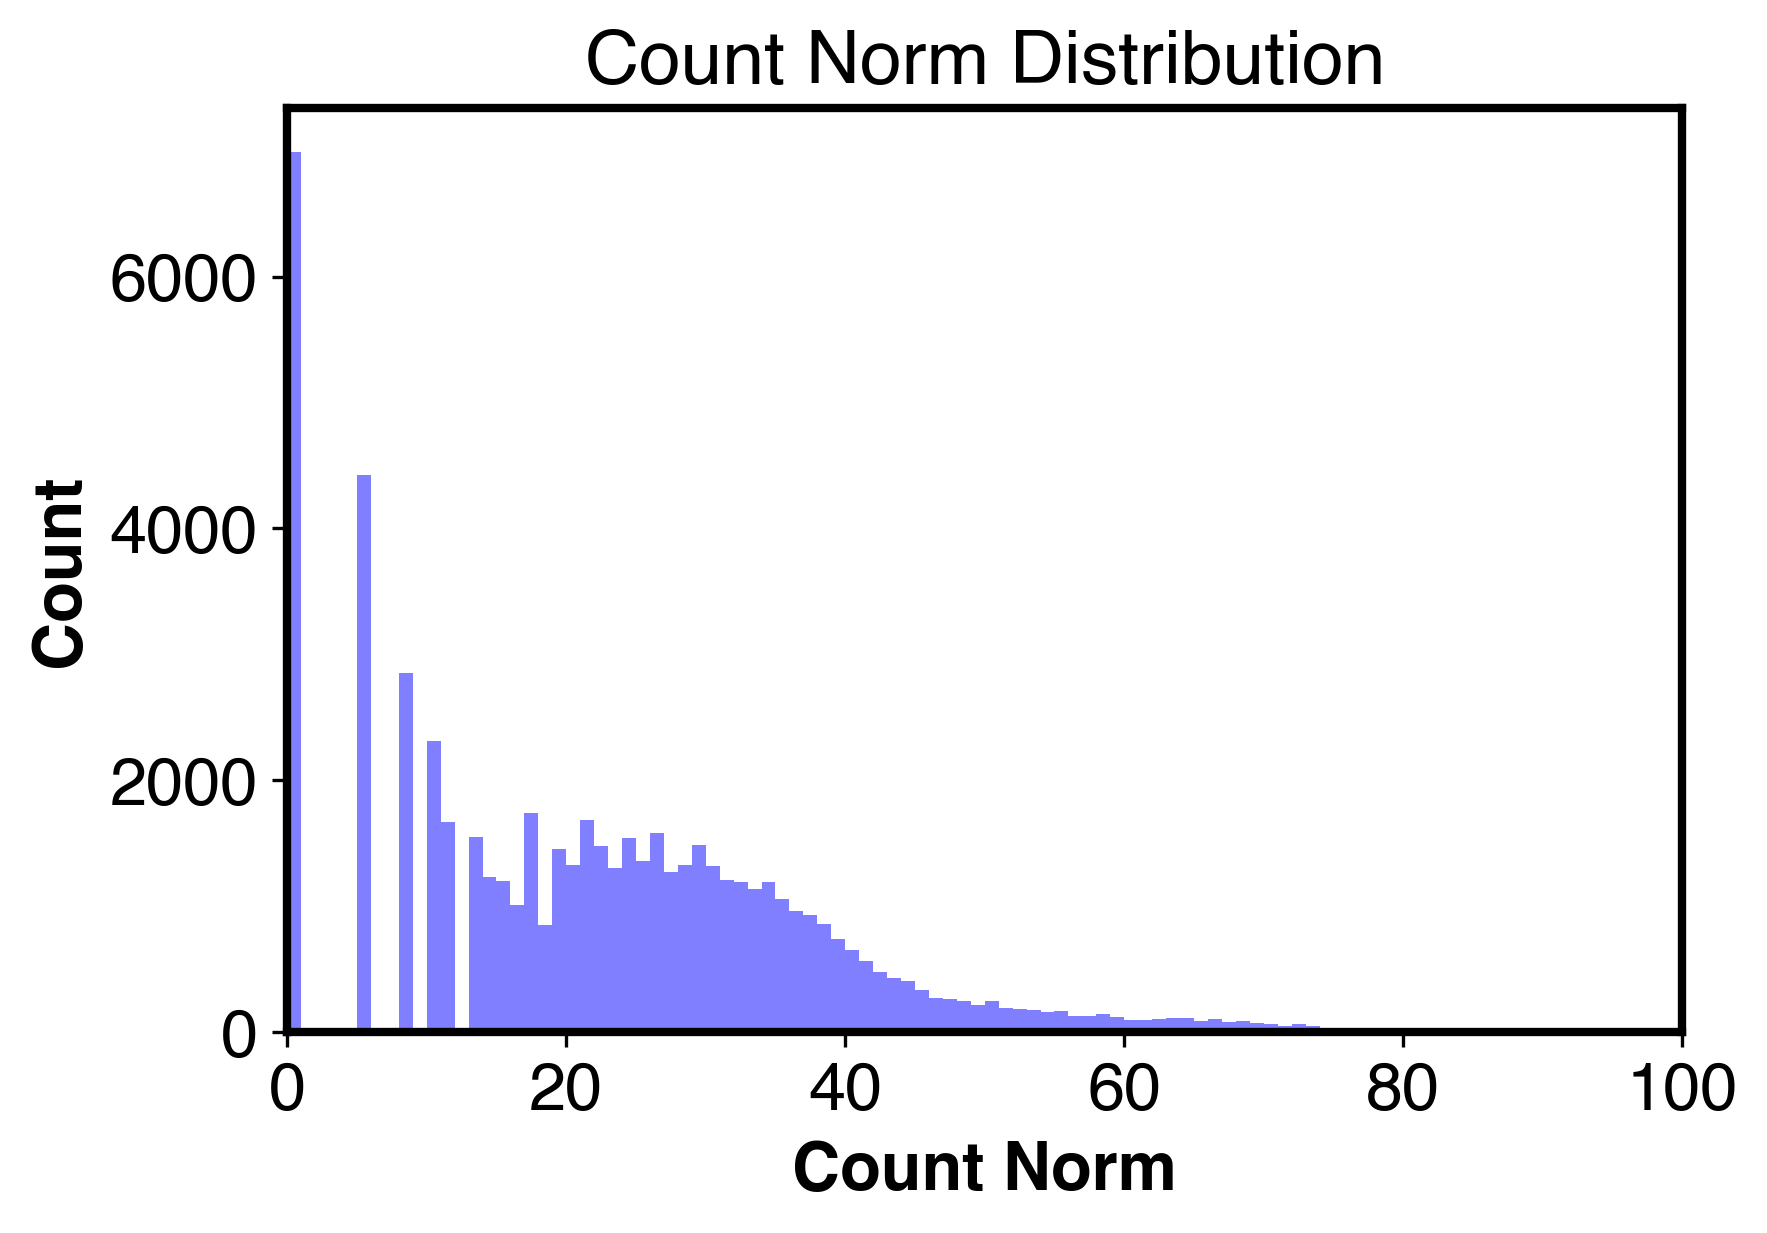

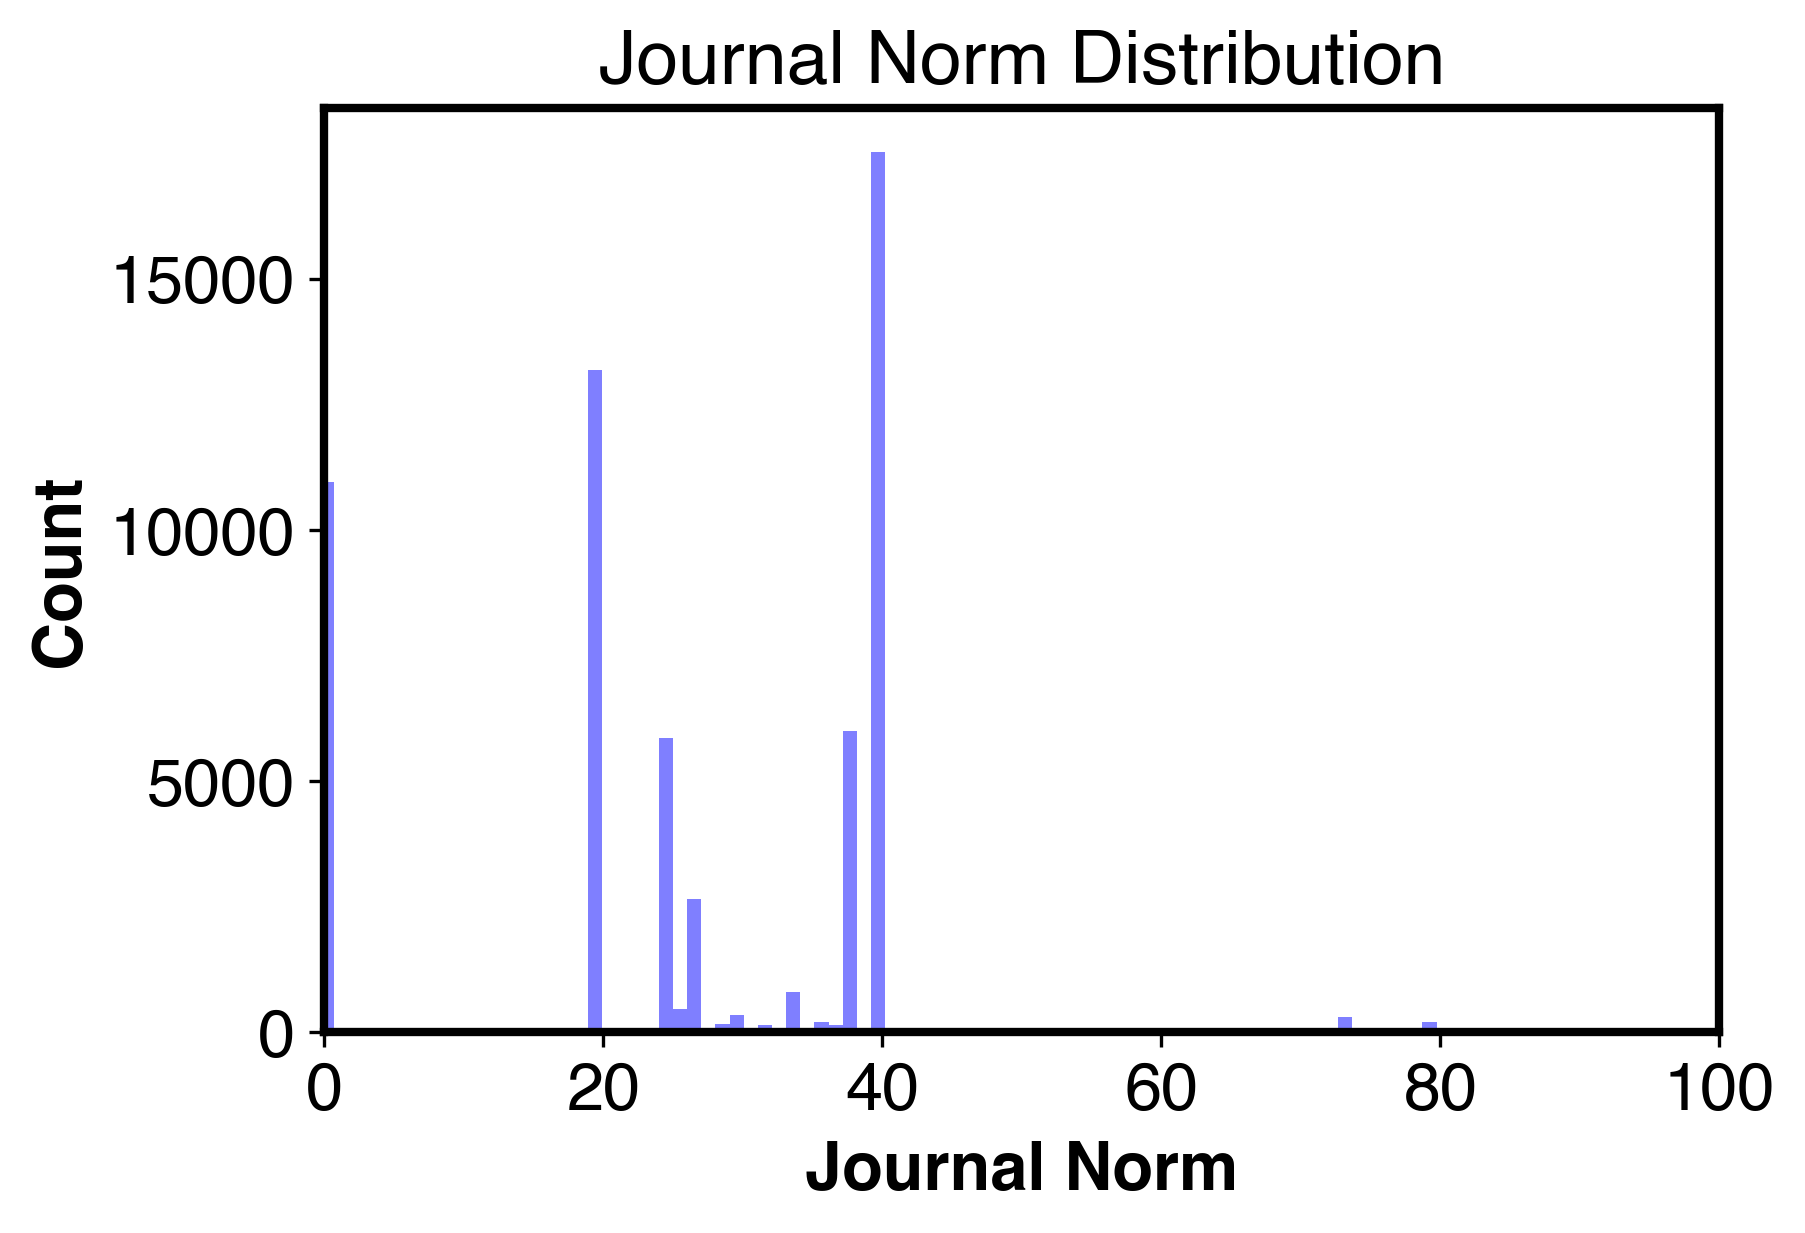

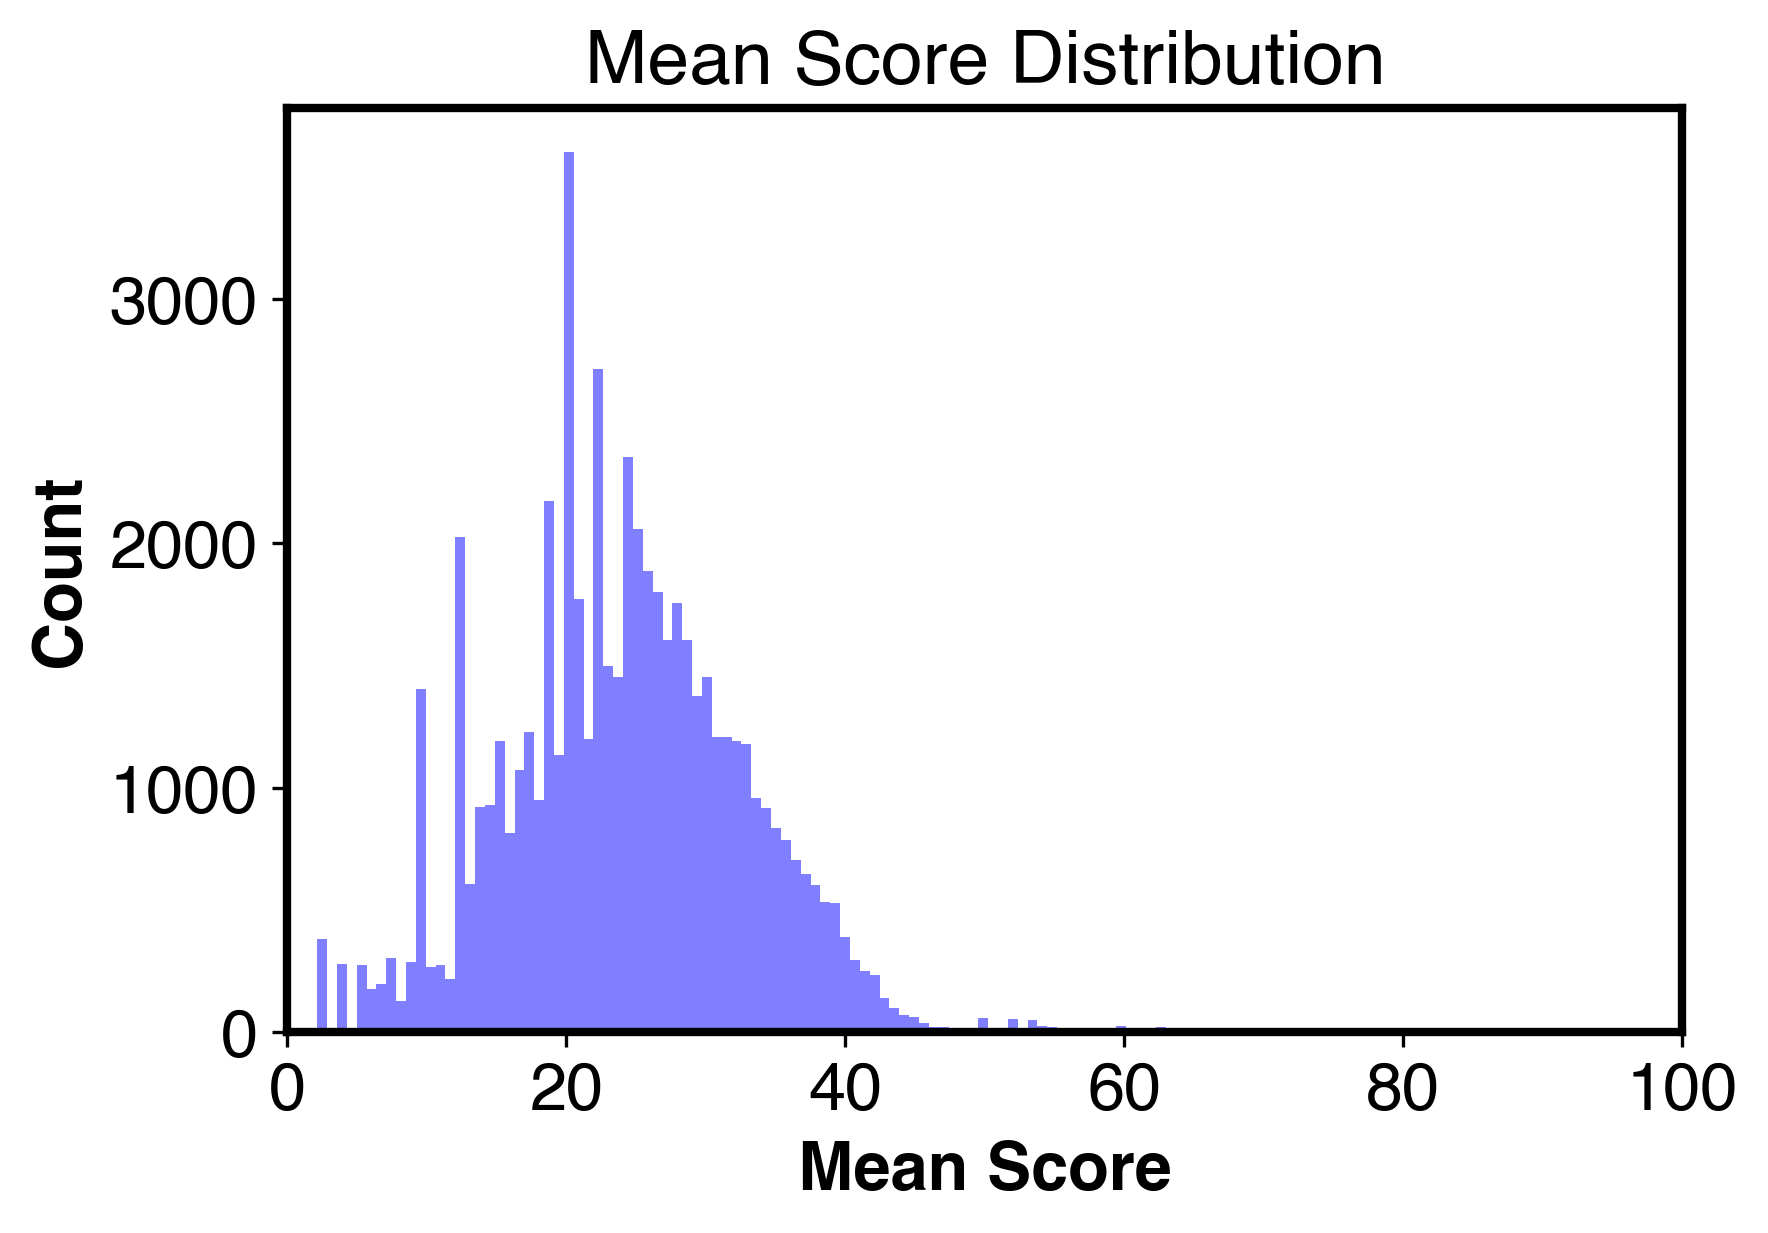

In [7]:
print("assay scoreing")
assay_scores = {}
for name, assay in tqdm(assay_pairs_filtered.items(), ncols=80):
    if name in assay_pairs:
        item = lmdb[assay[0][0]]
        assay_scores[name] = {
            "count": np.log(len(assay_pairs[name])),
            "journal": np.log(impact_factots_mapping[item["journal"]]) if item["journal"] != "" else 0,
        }

max_count = max([x["count"] for x in assay_scores.values()])
max_journal = max([x["journal"] for x in assay_scores.values()])
journal_zero_count = 0
for name, assay_score in assay_scores.items():
    if assay_score["journal"] == 0:
        journal_zero_count += 1
    assay_score["count_norm"] = assay_score["count"] / max_count * 100
    assay_score["journal_norm"] = assay_score["journal"] / max_journal * 100
    assay_score["mean_score"] = (
        assay_score["count_norm"] + assay_score["journal_norm"]
    ) / 2
print(f"total assay: {len(assay_scores)}")
print(f"journal zero assay: {journal_zero_count}")

# plot count_norm dist
plt.figure(figsize=(6, 4))
plt.hist(
    [x["count_norm"] for x in assay_scores.values()],
    bins=100,
    color="blue",
    alpha=0.5,
)
plt.xlabel("Count Norm")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.title("Count Norm Distribution")
plt.show()

# plot journal_norm dist
plt.figure(figsize=(6, 4))
plt.hist(
    [x["journal_norm"] for x in assay_scores.values()],
    bins=100,
    color="blue",
    alpha=0.5,
)
plt.xlabel("Journal Norm")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.title("Journal Norm Distribution")
plt.show()

# plot mean_score dist
plt.figure(figsize=(6, 4))
plt.hist(
    [x["mean_score"] for x in assay_scores.values()],
    bins=100,
    color="blue",
    alpha=0.5,
)
plt.xlabel("Mean Score")
plt.ylabel("Count")
plt.xlim(0, 100)
plt.title("Mean Score Distribution")
plt.show()


In [8]:
print("group assay by uniprot id and sort by score")
assay_train_grouped_by_uniprot = {}
for name, assay in assay_pairs_30_train.items():
    uniprot_id = name.split("_")[-2]
    if uniprot_id not in assay_train_grouped_by_uniprot:
        assay_train_grouped_by_uniprot[uniprot_id] = []
    assay_train_grouped_by_uniprot[uniprot_id].append({
        "name": name,
        "pairs": len(assay_pairs[name]),
        "journal_socre": assay_scores[name]["journal_norm"],
        "count_score": assay_scores[name]["count_norm"],
        "score": assay_scores[name]["mean_score"],
    })

for assay_id in assay_train_grouped_by_uniprot:
    assay_train_grouped_by_uniprot[assay_id] = sorted(
        assay_train_grouped_by_uniprot[assay_id],
        key=lambda x: x["score"],
        reverse=True,
    )

assay_val_grouped_by_uniprot = {}
for name, assay in assay_pairs_30_valid.items():
    uniprot_id = name.split("_")[-2]
    if uniprot_id not in assay_val_grouped_by_uniprot:
        assay_val_grouped_by_uniprot[uniprot_id] = []
    assay_val_grouped_by_uniprot[uniprot_id].append({
        "name": name,
        "pairs": len(assay_pairs[name]),
        "journal_socre": assay_scores[name]["journal_norm"],
        "count_score": assay_scores[name]["count_norm"],
        "score": assay_scores[name]["mean_score"],
    })
for assay_id in assay_val_grouped_by_uniprot:
    assay_val_grouped_by_uniprot[assay_id] = sorted(
        assay_val_grouped_by_uniprot[assay_id],
        key=lambda x: x["score"],
        reverse=True,
    )

print(f"total train uniprot id: {len(assay_train_grouped_by_uniprot)}")
print(f"total valid uniprot id: {len(assay_val_grouped_by_uniprot)}")
print(f"example uniprot assay: {list(assay_train_grouped_by_uniprot.items())[0]}")

group assay by uniprot id and sort by score
total train uniprot id: 2580
total valid uniprot id: 1188
example uniprot assay: ('A0A024AXB9', [{'name': 'group_CHEMBL4811973_A0A024AXB9_IC50', 'pairs': 1679, 'journal_socre': 40.15172058649668, 'count_score': 55.07261144199609, 'score': 47.612166014246384}, {'name': 'group_CHEMBL4844502_A0A024AXB9_IC50', 'pairs': 832, 'journal_socre': 37.24640334529894, 'count_score': 49.86551606897107, 'score': 43.555959707135}, {'name': 'group_CHEMBL4338583_A0A024AXB9_IC50', 'pairs': 89, 'journal_socre': 40.15172058649668, 'count_score': 33.28877853406308, 'score': 36.72024956027988}, {'name': 'group_CHEMBL4407783_A0A024AXB9_IC50', 'pairs': 42, 'journal_socre': 37.24640334529894, 'count_score': 27.71943323267152, 'score': 32.48291828898523}, {'name': 'group_CHEMBL4825419_A0A024AXB9_IC50', 'pairs': 118, 'journal_socre': 24.81879883291366, 'count_score': 35.38051444545383, 'score': 30.099656639183742}, {'name': 'group_CHEMBL4356009_A0A024AXB9_IC50', 'pairs'

In [9]:
print("obatain assay sample order based on assay scores")

assay_train_sample_order = []
loop_train = 0
loop_note_train = []
while True:
    all_empty = True
    loop_train += 1
    for uniprot_id in assay_train_grouped_by_uniprot:
        if len(assay_train_grouped_by_uniprot[uniprot_id]) > 0:
            assay_train_sample_order.append(assay_train_grouped_by_uniprot[uniprot_id].pop(0))
            all_empty = False
            loop_note_train.append((len(assay_train_sample_order), loop_train))
    if all_empty:
        break
print(f"total train assay sample order: {len(assay_train_sample_order)}")

assay_val_sample_order = []
loop_val = 0
loop_note_val = []
while True:
    all_empty = True
    loop_val += 1
    for uniprot_id in assay_val_grouped_by_uniprot:
        if len(assay_val_grouped_by_uniprot[uniprot_id]) > 0:
            assay_val_sample_order.append(assay_val_grouped_by_uniprot[uniprot_id].pop(0))
            all_empty = False
            loop_note_val.append((len(assay_val_sample_order), loop_val))
    if all_empty:
        break
print(f"total val assay sample order: {len(assay_val_sample_order)}")

obatain assay sample order based on assay scores
total train assay sample order: 25052
total val assay sample order: 34192


total train assay sample order: 25052
total val assay sample order: 34192


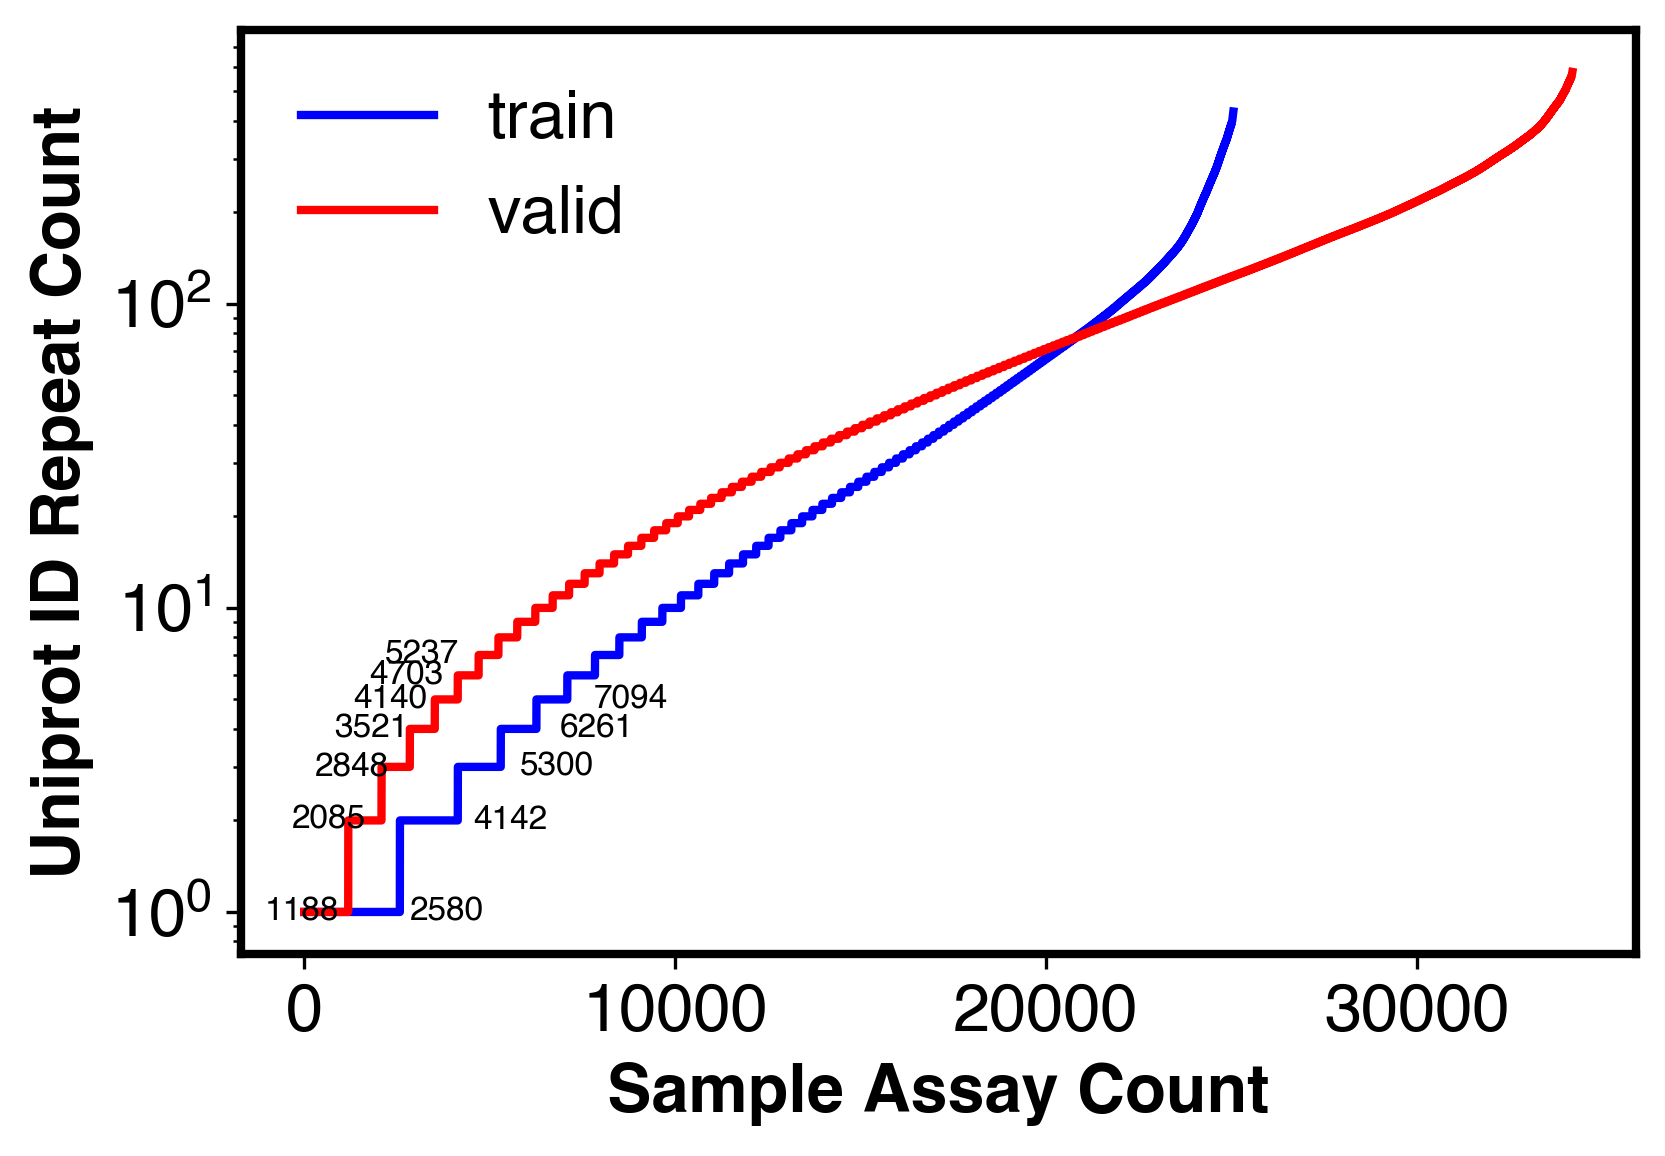

In [10]:
print(f"total train assay sample order: {len(assay_train_sample_order)}")
print(f"total val assay sample order: {len(assay_val_sample_order)}")
# plot loop note with lines
plt.figure(figsize=(6, 4))
plt.plot(
    [x[0] for x in loop_note_train],
    [x[1] for x in loop_note_train],
    color="blue",
    label="train",
)
plt.plot(
    [x[0] for x in loop_note_val],
    [x[1] for x in loop_note_val],
    color="red",
    label="valid",
)
plt.xlabel("Sample Assay Count")
plt.ylabel("Uniprot ID Repeat Count")
plt.yscale("log")
plt.legend()

# add text to the top of each point for the first 10 points
inflection_points_train = []
for i in range(10):
    loop_note_train_arr = np.array(loop_note_train)
    max_x = loop_note_train_arr[loop_note_train_arr[:, 1] == i + 1].max(axis=0)[0]
    inflection_points_train.append((max_x, i + 1))
    
for i in range(5):
    plt.text(
        inflection_points_train[i][0] * 1.1,
        inflection_points_train[i][1],
        f"{inflection_points_train[i][0]}",
        color="black",
        va="center",
        fontsize=8,
    )

inflection_points_val = []
for i in range(10):
    loop_note_val_arr = np.array(loop_note_val)
    max_x = loop_note_val_arr[loop_note_val_arr[:, 1] == i + 1].max(axis=0)[0]
    inflection_points_val.append((max_x, i + 1))
for i in range(7):
    plt.text(
        inflection_points_val[i][0] * 0.8,
        inflection_points_val[i][1],
        f"{inflection_points_val[i][0]}",
        color="black",
        va="center",
        ha="right",
        fontsize=8,
    )

In [11]:
train_30_cluster = {}
with open("../scripts/sample/cluster30/train30.cluster/id30_cluster.tsv") as f:
    for line in f:
        if line.strip():
            center, uniprot_id = line.strip().split("\t")
            if center not in train_30_cluster:
                train_30_cluster[center] = set()
            train_30_cluster[center].add(uniprot_id)
print(f"total train cluster: {len(train_30_cluster)}")

full_train_30_uniprot_id = set(assay_train_grouped_by_uniprot.keys())
print(f"total train uniprot id: {len(full_train_30_uniprot_id)}")

val_30_cluster = {}
with open("../scripts/sample/cluster30/valid30.cluster/id30_cluster.tsv") as f:
    for line in f:
        if line.strip():
            center, uniprot_id = line.strip().split("\t")
            if center not in val_30_cluster:
                val_30_cluster[center] = set()
            val_30_cluster[center].add(uniprot_id)
print(f"total val cluster: {len(val_30_cluster)}")
full_val_30_uniprot_id = set(assay_val_grouped_by_uniprot.keys())
print(f"total val uniprot id: {len(full_val_30_uniprot_id)}")

total train cluster: 1995
total train uniprot id: 2580
total val cluster: 381
total val uniprot id: 1188


In [12]:
import math
import random

def get_safe_uniprot_ids(uniprot_id, full_uniprot_ids, uniprot_id_30_cluster):
    uniprot_ids_not_safe = set() 
    for cluster in uniprot_id_30_cluster.values():
        if uniprot_id not in cluster:
            for id_ in cluster:
                if id_ in full_uniprot_ids:
                    uniprot_ids_not_safe.add(id_)
    return uniprot_ids_not_safe

def get_safe_records(safe_uniprot_ids, assay_group_by_uniprot, n_records):
    sample_records = []
    n_uniprot_ids = min(n_records, len(safe_uniprot_ids))
    n_record_per_uniprot_id = math.ceil(n_records / n_uniprot_ids)
    for _ in range(n_uniprot_ids):
        uniprot_id = random.choice(list(safe_uniprot_ids))
        if uniprot_id in assay_group_by_uniprot:
            for _ in range(n_record_per_uniprot_id):
                assay = random.choice(assay_group_by_uniprot[uniprot_id])
                sample_records.append(random.choice(assay["records"]))
    return sample_records

In [13]:
from itertools import chain

assay_records_30_train_grouped_by_uniprot = {}
for name, assay in assay_pairs_30_train.items():
    uniprot_id = name.split("_")[-2]
    if uniprot_id not in assay_records_30_train_grouped_by_uniprot:
        assay_records_30_train_grouped_by_uniprot[uniprot_id] = []
    records = set()
    for pair in assay:
        records.add(pair[0])
        records.add(pair[1])
    assay_records_30_train_grouped_by_uniprot[uniprot_id].append({
        "name": name,
        "records": list(records),
    })

In [14]:
assay_records_30_valid_grouped_by_uniprot = {}
for name, assay in assay_pairs_30_valid.items():
    uniprot_id = name.split("_")[-2]
    if uniprot_id not in assay_records_30_valid_grouped_by_uniprot:
        assay_records_30_valid_grouped_by_uniprot[uniprot_id] = []
    records = set()
    for pair in assay:
        records.add(pair[0])
        records.add(pair[1])
    assay_records_30_valid_grouped_by_uniprot[uniprot_id].append({
        "name": name,
        "records": list(records),
    })

In [24]:
random.seed(0)
# uniprot_id_mol_set = {}
n_sample_assay = 4500
n_pair_per_assay = 4
strong_weak_full_pairs = []
positive_negative_full_pairs = []

# pair_inputs = set()
triplet_inputs = set()

for assay in tqdm(assay_train_sample_order[:n_sample_assay], ncols=80):
    pairs = assay_pairs[assay["name"]].copy()
    random.shuffle(pairs)
    strong_weak_pairs = pairs[:n_pair_per_assay]
    strong_weak_full_pairs.extend(strong_weak_pairs)

    uniprot_id = assay["name"].split("_")[-2]
    safe_uniprot_ids = get_safe_uniprot_ids(
        uniprot_id,
        full_train_30_uniprot_id,
        train_30_cluster,
    )
    positive_records = set()
    for pair in strong_weak_pairs:
        positive_records.add(pair[0])
        positive_records.add(pair[1])

        # pair_inputs.add((assay["name"], pair[0]))
        # pair_inputs.add((assay["name"], pair[1]))
        triplet_inputs.add((assay["name"], pair[0], pair[1]))

    # positive_records = list(positive_records)

    # negative_records = get_safe_records(
    #     safe_uniprot_ids,
    #     assay_records_30_train_grouped_by_uniprot,
    #     int(n_pair_per_assay / 2),
    # )

    # for _ in range(n_pair_per_assay):
    #     postive = random.choice(positive_records)
    #     negative = random.choice(negative_records)
    #     positive_negative_full_pairs.append((postive, negative))

    #     triplet_inputs.add((assay["name"], postive, negative))

    # for negative_record in negative_records:
    #     # pair_inputs.add((assay["name"], negative_record))

    #     positive_negative_full_pairs.append((postive, negative_record))
    #     triplet_inputs.add((assay["name"], postive, negative_record))


n_total_pair_inputs = 10000
triplet_inputs = random.sample(
    list(triplet_inputs),
    n_total_pair_inputs,
)
pair_inputs = set()
for triplet in triplet_inputs:
    pair_inputs.add((triplet[0], triplet[1]))
    pair_inputs.add((triplet[0], triplet[2]))

print(f"total strong weak pairs: {len(strong_weak_full_pairs)}")
print(f"total positive negative pairs: {len(positive_negative_full_pairs)}")
print(f"total pairs: {len(strong_weak_full_pairs) + len(positive_negative_full_pairs)}")

print(f"total pair inputs: {len(pair_inputs)}")
print(f"total triplet inputs: {len(triplet_inputs)}")

100%|██████████████████████████████████████| 4500/4500 [00:08<00:00, 544.00it/s]

total strong weak pairs: 16195
total positive negative pairs: 0
total pairs: 16195
total pair inputs: 17811
total triplet inputs: 10000


In [25]:
import pickle as pkl
with open("/data/rerank/protenix/chembl_bdb/sample_1w_0.5_1.0/pair_inputs.pkl", "wb") as f:
    pkl.dump(pair_inputs, f)
with open("/data/rerank/protenix/chembl_bdb/sample_1w_0.5_1.0/triplet_inputs.pkl", "wb") as f:
    pkl.dump(triplet_inputs, f)

In [27]:
print("construct json based on pair_inputs and triplet_inputs")
triplet_json = []
for triplet in tqdm(triplet_inputs, ncols=80):
    uniprot_id = triplet[0].split("_")[-2]
    ligand1 = lmdb[triplet[1]]
    ligand2 = lmdb[triplet[2]]

    name = f"{uniprot_id}/{ligand1['name']}/{ligand2['name']}"
    base_json = ligand1["sequences"]
    base_json.append(ligand2["sequences"][-1])
    triplet_json.append(
        {
            "name": name,
            "sequences": base_json,
        }
    )
with open(
    "/data/rerank/protenix/chembl_bdb/sample_1w_0.5_1.0/triplet.json", "w"
) as f:
    json.dump(triplet_json, f, indent=2)

construct json based on pair_inputs and triplet_inputs


100%|██████████████████████████████████| 10000/10000 [00:00<00:00, 13811.81it/s]


In [28]:
pair_json = []
for pair in tqdm(pair_inputs, ncols=80):
    uniprot_id = pair[0].split("_")[-2]
    ligand = lmdb[pair[1]]

    name = f"{uniprot_id}/{ligand['name']}"

    assay = lmdb[assay_pairs_30_train[pair[0]][0][0]]
    base_json = assay["sequences"]
    base_json[-1] = ligand["sequences"][-1]
    pair_json.append({
        "name": name,
        "sequences": base_json,
    })
with open("/data/rerank/protenix/chembl_bdb/sample_1w_0.5_1.0/pair.json", "w") as f:
    json.dump(pair_json, f, indent=2)

100%|██████████████████████████████████| 17811/17811 [00:00<00:00, 33631.20it/s]


In [29]:
random.seed(0)
# uniprot_id_mol_set = {}
n_sample_assay = 12000
n_pair_per_assay = 20
strong_weak_full_pairs = []
positive_negative_full_pairs = []

# pair_inputs = set()
triplet_inputs = set()

for assay in tqdm(assay_train_sample_order[:n_sample_assay], ncols=80):
    pairs = assay_pairs[assay["name"]].copy()
    random.shuffle(pairs)
    strong_weak_pairs = pairs[:n_pair_per_assay]
    strong_weak_full_pairs.extend(strong_weak_pairs)

    uniprot_id = assay["name"].split("_")[-2]
    safe_uniprot_ids = get_safe_uniprot_ids(
        uniprot_id,
        full_train_30_uniprot_id,
        train_30_cluster,
    )
    positive_records = set()
    for pair in strong_weak_pairs:
        positive_records.add(pair[0])
        positive_records.add(pair[1])

        # pair_inputs.add((assay["name"], pair[0]))
        # pair_inputs.add((assay["name"], pair[1]))
        triplet_inputs.add((assay["name"], pair[0], pair[1]))

    # positive_records = list(positive_records)

    # negative_records = get_safe_records(
    #     safe_uniprot_ids,
    #     assay_records_30_train_grouped_by_uniprot,
    #     int(n_pair_per_assay / 2),
    # )

    # for _ in range(len(strong_weak_pairs)):
    #     postive = random.choice(positive_records)
    #     negative = random.choice(negative_records)
    #     positive_negative_full_pairs.append((postive, negative))

    #     triplet_inputs.add((assay["name"], postive, negative))

    # for negative_record in negative_records:
    #     # pair_inputs.add((assay["name"], negative_record))

    #     positive_negative_full_pairs.append((postive, negative_record))
    #     triplet_inputs.add((assay["name"], postive, negative_record))


n_total_pair_inputs = 100000
triplet_inputs = random.sample(
    list(triplet_inputs),
    n_total_pair_inputs,
)
pair_inputs = set()
for triplet in triplet_inputs:
    pair_inputs.add((triplet[0], triplet[1]))
    pair_inputs.add((triplet[0], triplet[2]))

print(f"total strong weak pairs: {len(strong_weak_full_pairs)}")
print(f"total positive negative pairs: {len(positive_negative_full_pairs)}")
print(f"total pairs: {len(strong_weak_full_pairs) + len(positive_negative_full_pairs)}")

print(f"total pair inputs: {len(pair_inputs)}")
print(f"total triplet inputs: {len(triplet_inputs)}")

  0%|                                                 | 0/12000 [00:00<?, ?it/s]

100%|████████████████████████████████████| 12000/12000 [00:15<00:00, 772.25it/s]


total strong weak pairs: 171064
total positive negative pairs: 0
total pairs: 171064
total pair inputs: 135252
total triplet inputs: 100000


In [31]:
print("construct json based on pair_inputs and triplet_inputs")
triplet_json = []
for triplet in tqdm(triplet_inputs, ncols=80):
    uniprot_id = triplet[0].split("_")[-2]
    ligand1 = lmdb[triplet[1]]
    ligand2 = lmdb[triplet[2]]

    name = f"{uniprot_id}/{ligand1['name']}/{ligand2['name']}"
    base_json = ligand1["sequences"]
    base_json.append(ligand2["sequences"][-1])
    triplet_json.append(
        {
            "name": name,
            "sequences": base_json,
        }
    )
with open(
    "/data/rerank/protenix/chembl_bdb/sample_10w_0.5_1.0/triplet.json", "w"
) as f:
    json.dump(triplet_json, f, indent=2)

construct json based on pair_inputs and triplet_inputs


100%|████████████████████████████████| 100000/100000 [00:06<00:00, 16085.67it/s]


In [33]:
pair_json = []
for pair in tqdm(pair_inputs, ncols=80):
    uniprot_id = pair[0].split("_")[-2]
    ligand = lmdb[pair[1]]

    name = f"{uniprot_id}/{ligand['name']}"

    assay = lmdb[assay_pairs_30_train[pair[0]][0][0]]
    base_json = assay["sequences"]
    base_json[-1] = ligand["sequences"][-1]
    pair_json.append({
        "name": name,
        "sequences": base_json,
    })
with open("/data/rerank/protenix/chembl_bdb/sample_10w_0.5_1.0/pair.json", "w") as f:
    json.dump(pair_json, f, indent=2)

100%|████████████████████████████████| 135252/135252 [00:03<00:00, 34293.51it/s]


In [ ]:
print("sample validation")
random.seed(0)
# uniprot_id_mol_set = {}
n_sample_assay = 2025
n_pair_per_assay = 2
strong_weak_full_pairs = []
positive_negative_full_pairs = []

# pair_inputs = set()
triplet_inputs = set()

for assay in tqdm(assay_val_sample_order[:n_sample_assay], ncols=80):
    pairs = assay_pairs[assay["name"]].copy()
    random.shuffle(pairs)
    strong_weak_pairs = pairs[:n_pair_per_assay]
    strong_weak_full_pairs.extend(strong_weak_pairs)

    uniprot_id = assay["name"].split("_")[-2]
    safe_uniprot_ids = get_safe_uniprot_ids(
        uniprot_id,
        full_val_30_uniprot_id,
        val_30_cluster,
    )
    positive_records = set()
    for pair in strong_weak_pairs:
        positive_records.add(pair[0])
        positive_records.add(pair[1])

        # pair_inputs.add((assay["name"], pair[0]))
        # pair_inputs.add((assay["name"], pair[1]))
        triplet_inputs.add((assay["name"], pair[0], pair[1]))

    positive_records = list(positive_records)

    negative_records = get_safe_records(
        safe_uniprot_ids,
        assay_records_30_valid_grouped_by_uniprot,
        int(n_pair_per_assay / 2),
    )

    for _ in range(len(strong_weak_pairs)):
        postive = random.choice(positive_records)
        negative = random.choice(negative_records)
        positive_negative_full_pairs.append((postive, negative))

        triplet_inputs.add((assay["name"], postive, negative))

    # for negative_record in negative_records:
    #     # pair_inputs.add((assay["name"], negative_record))

    #     positive_negative_full_pairs.append((postive, negative_record))
    #     triplet_inputs.add((assay["name"], postive, negative_record))


n_total_pair_inputs = 5000
triplet_inputs = random.sample(
    list(triplet_inputs),
    n_total_pair_inputs,
)
pair_inputs = set()
for triplet in triplet_inputs:
    pair_inputs.add((triplet[0], triplet[1]))
    pair_inputs.add((triplet[0], triplet[2]))

print(f"total strong weak pairs: {len(strong_weak_full_pairs)}")
print(f"total positive negative pairs: {len(positive_negative_full_pairs)}")
print(f"total pairs: {len(strong_weak_full_pairs) + len(positive_negative_full_pairs)}")

print(f"total pair inputs: {len(pair_inputs)}")
print(f"total triplet inputs: {len(triplet_inputs)}")

sample validation


100%|██████████████████████████████████████| 2025/2025 [00:02<00:00, 971.89it/s]

total strong weak pairs: 3956
total positive negative pairs: 3956
total pairs: 7912
total pair inputs: 7500
total triplet inputs: 5000


In [19]:
import pickle as pkl
with open("/data/rerank/protenix/chembl_bdb/sample_val/sample_val_pair_inputs.pkl", "wb") as f:
    pkl.dump(pair_inputs, f)
with open("/data/rerank/protenix/chembl_bdb/sample_val/sample_val_triplet_inputs.pkl", "wb") as f:
    pkl.dump(triplet_inputs, f)

In [20]:
print("construct json based on pair_inputs and triplet_inputs")
triplet_json = []
for triplet in tqdm(triplet_inputs, ncols=80):
    uniprot_id = triplet[0].split("_")[-2]
    ligand1 = lmdb[triplet[1]]
    ligand2 = lmdb[triplet[2]]

    name = f"{uniprot_id}/{ligand1['name']}/{ligand2['name']}"
    base_json = ligand1["sequences"]
    base_json.append(ligand2["sequences"][-1])
    triplet_json.append(
        {
            "name": name,
            "sequences": base_json,
            "len": (
                ligand1["len"]["protein"],
                ligand1["len"]["ligand"],
                ligand2["len"]["ligand"],
            ),
        }
    )
with open(
    "/data/rerank/protenix/chembl_bdb/sample_val/sample_val_triplet.json", "w"
) as f:
    json.dump(triplet_json, f, indent=2)

construct json based on pair_inputs and triplet_inputs


100%|█████████████████████████████████████| 5000/5000 [00:01<00:00, 3343.40it/s]


In [23]:
pair_json = []
for pair in tqdm(pair_inputs, ncols=80):
    uniprot_id = pair[0].split("_")[-2]
    ligand = lmdb[pair[1]]

    name = f"{uniprot_id}/{ligand['name']}"

    assay = lmdb[assay_pairs_30_valid[pair[0]][0][0]]
    base_json = assay["sequences"]
    base_json[-1] = ligand["sequences"][-1]
    pair_json.append({
        "name": name,
        "sequences": base_json,
        "len": (
            assay["len"]["protein"],
            ligand["len"]["ligand"],
        ),
    })
with open("/data/rerank/protenix/chembl_bdb/sample_val/sample_val_pair.json", "w") as f:
    json.dump(pair_json, f, indent=2)

100%|████████████████████████████████████| 7500/7500 [00:00<00:00, 31494.10it/s]


In [2]:
with open("/data/rerank/protenix/chembl_bdb/sample_3w/sample_3w_triplet.json") as f:
    triplet_json = json.load(f)
triplet_3w_keys = [x["name"] for x in triplet_json]
with open("/data/rerank/protenix/chembl_bdb/sample_30w/sample_30w_triplet.json") as f:
    triplet_json = json.load(f)
triplet_30w_keys = [x["name"] for x in triplet_json]
with open("/data/rerank/protenix/chembl_bdb/sample_val/sample_val_triplet.json") as f:
    triplet_json = json.load(f)
triplet_val_keys = [x["name"] for x in triplet_json]
    

In [5]:
with open("/data/rerank/protenix/chembl_bdb/sample_3w/sample_3w_triplet.json") as f:
    triplet_json = json.load(f)
triplet_3w_keys = [x["name"] for x in triplet_json]
with open("/data/rerank/protenix/chembl_bdb/sample_3w/sample_3w_pair.json") as f:
    pair_json = json.load(f)
pair_3w_keys = [x["name"] for x in pair_json]

In [6]:
len(pair_3w_keys)

34312

In [33]:
len(triplet_val_keys)

5000

In [3]:

lmdb_meta = LMDBDataset("/data/rerank/protenix/chembl_bdb/chembl_bdb_meta.lmdb", readonly=False)
lmdb_meta["train_3w"] = triplet_3w_keys
lmdb_meta["train_30w"] = triplet_30w_keys
lmdb_meta["val_5k"] = triplet_val_keys

In [42]:
random.choice(triplet_30w_keys)

'P00492/P00492_a9f40bf8ba46600cde84fff06d41623f/P00492_30743cf35258d201033e0654f6d556f2'

In [44]:
lmdb_meta["P00492_a9f40bf8ba46600cde84fff06d41623f"]

{'name': 'P00492_a9f40bf8ba46600cde84fff06d41623f',
 'assay_id': 'CHEMBL3396536',
 'uniprot_id': 'P00492',
 'source': 'ChEMBL',
 'journal': 'J Med Chem',
 'patent': '',
 'sequences': [{'proteinChain': {'sequence': 'MATRSPGVVISDDEPGYDLDLFCIPNHYAEDLERVFIPHGLIMDRTERLARDVMKEMGGHHIVALCVLKGGYKFFADLLDYIKALNRNSDRSIPMTVDFIRLKSYCNDQSTGDIKVIGGDDLSTLTGKNVLIVEDIIDTGKTMQTLLSLVRQYNPKMVKVASLLVKRTPRSVGYKPDFVGFEIPDKFVVGYALDYNEYFRDLNHVCVISETGKAKYKA',
    'count': 1,
    'msa': {'precomputed_msa_dir': '/data/rerank/protenix/chembl_bdb/precomputed_msa/P00492',
     'pairing_db': 'uniref100'}}},
  {'ligand': {'ligand': 'Nc1nc2c(nc(Br)n2CCN(CCOCCP(=O)(O)O)CCP(=O)(O)O)c(=O)[nH]1',
    'count': 1}}],
 'activity': {'type': 'KI', 'relation': '=', 'value': 40.0, 'units': 'nM'},
 'assay_group': 'group_CHEMBL3396536_P00492_KI'}

In [43]:
lmdb_meta["P00492_30743cf35258d201033e0654f6d556f2"]

{'name': 'P00492_30743cf35258d201033e0654f6d556f2',
 'assay_id': 'CHEMBL3396536',
 'uniprot_id': 'P00492',
 'source': 'ChEMBL',
 'journal': 'J Med Chem',
 'patent': '',
 'sequences': [{'proteinChain': {'sequence': 'MATRSPGVVISDDEPGYDLDLFCIPNHYAEDLERVFIPHGLIMDRTERLARDVMKEMGGHHIVALCVLKGGYKFFADLLDYIKALNRNSDRSIPMTVDFIRLKSYCNDQSTGDIKVIGGDDLSTLTGKNVLIVEDIIDTGKTMQTLLSLVRQYNPKMVKVASLLVKRTPRSVGYKPDFVGFEIPDKFVVGYALDYNEYFRDLNHVCVISETGKAKYKA',
    'count': 1,
    'msa': {'precomputed_msa_dir': '/data/rerank/protenix/chembl_bdb/precomputed_msa/P00492',
     'pairing_db': 'uniref100'}}},
  {'ligand': {'ligand': 'O=c1[nH]cnc2c1ncn2CCN(CCCCP(=O)(O)O)CCP(=O)(O)O',
    'count': 1}}],
 'activity': {'type': 'KI', 'relation': '=', 'value': 4000.0, 'units': 'nM'},
 'assay_group': 'group_CHEMBL3396536_P00492_KI'}

In [15]:
print("sample validation 3w")
random.seed(0)
# uniprot_id_mol_set = {}
n_sample_assay = 4500
n_pair_per_assay = 4
strong_weak_full_pairs = []
positive_negative_full_pairs = []

# pair_inputs = set()
triplet_inputs = set()

for assay in tqdm(assay_val_sample_order[:n_sample_assay], ncols=80):
    pairs = assay_pairs[assay["name"]].copy()
    random.shuffle(pairs)
    strong_weak_pairs = pairs[:n_pair_per_assay]
    strong_weak_full_pairs.extend(strong_weak_pairs)

    uniprot_id = assay["name"].split("_")[-2]
    safe_uniprot_ids = get_safe_uniprot_ids(
        uniprot_id,
        full_val_30_uniprot_id,
        val_30_cluster,
    )
    positive_records = set()
    for pair in strong_weak_pairs:
        positive_records.add(pair[0])
        positive_records.add(pair[1])

        # pair_inputs.add((assay["name"], pair[0]))
        # pair_inputs.add((assay["name"], pair[1]))
        triplet_inputs.add((assay["name"], pair[0], pair[1]))

    # positive_records = list(positive_records)

    # negative_records = get_safe_records(
    #     safe_uniprot_ids,
    #     assay_records_30_valid_grouped_by_uniprot,
    #     int(n_pair_per_assay / 2),
    # )

    # for _ in range(len(strong_weak_pairs)):
    #     postive = random.choice(positive_records)
    #     negative = random.choice(negative_records)
    #     positive_negative_full_pairs.append((postive, negative))

    #     triplet_inputs.add((assay["name"], postive, negative))

    # for negative_record in negative_records:
    #     # pair_inputs.add((assay["name"], negative_record))

    #     positive_negative_full_pairs.append((postive, negative_record))
    #     triplet_inputs.add((assay["name"], postive, negative_record))


n_total_pair_inputs = 10000
triplet_inputs = random.sample(
    list(triplet_inputs),
    n_total_pair_inputs,
)
pair_inputs = set()
for triplet in triplet_inputs:
    pair_inputs.add((triplet[0], triplet[1]))
    pair_inputs.add((triplet[0], triplet[2]))

print(f"total strong weak pairs: {len(strong_weak_full_pairs)}")
print(f"total positive negative pairs: {len(positive_negative_full_pairs)}")
print(f"total pairs: {len(strong_weak_full_pairs) + len(positive_negative_full_pairs)}")

print(f"total pair inputs: {len(pair_inputs)}")
print(f"total triplet inputs: {len(triplet_inputs)}")

sample validation 3w


100%|█████████████████████████████████████| 4500/4500 [00:04<00:00, 1097.87it/s]

total strong weak pairs: 16687
total positive negative pairs: 0
total pairs: 16687
total pair inputs: 17851
total triplet inputs: 10000


In [16]:
import pickle as pkl
with open("/data/rerank/protenix/chembl_bdb/sample_val_1w_0.5_1.0/pair_inputs.pkl", "wb") as f:
    pkl.dump(pair_inputs, f)
with open("/data/rerank/protenix/chembl_bdb/sample_val_1w_0.5_1.0/triplet_inputs.pkl", "wb") as f:
    pkl.dump(triplet_inputs, f)

In [18]:
print("construct json based on pair_inputs and triplet_inputs")
triplet_json = []
for triplet in tqdm(triplet_inputs, ncols=80):
    uniprot_id = triplet[0].split("_")[-2]
    ligand1 = lmdb[triplet[1]]
    ligand2 = lmdb[triplet[2]]

    name = f"{uniprot_id}/{ligand1['name']}/{ligand2['name']}"
    base_json = ligand1["sequences"]
    base_json.append(ligand2["sequences"][-1])
    triplet_json.append(
        {
            "name": name,
            "sequences": base_json,
        }
    )
with open(
    "/data/rerank/protenix/chembl_bdb/sample_val_1w_0.5_1.0/triplet.json", "w"
) as f:
    json.dump(triplet_json, f, indent=2)

construct json based on pair_inputs and triplet_inputs


100%|██████████████████████████████████| 10000/10000 [00:00<00:00, 22019.10it/s]


In [19]:
pair_json = []
for pair in tqdm(pair_inputs, ncols=80):
    uniprot_id = pair[0].split("_")[-2]
    ligand = lmdb[pair[1]]

    name = f"{uniprot_id}/{ligand['name']}"

    assay = lmdb[assay_pairs_30_valid[pair[0]][0][0]]
    base_json = assay["sequences"]
    base_json[-1] = ligand["sequences"][-1]
    pair_json.append({
        "name": name,
        "sequences": base_json
    })
with open("/data/rerank/protenix/chembl_bdb/sample_val_1w_0.5_1.0/pair.json", "w") as f:
    json.dump(pair_json, f, indent=2)

100%|██████████████████████████████████| 17851/17851 [00:00<00:00, 34088.06it/s]


In [18]:
print("sample validation 30w")
random.seed(0)
# uniprot_id_mol_set = {}
n_sample_assay = 12000
n_pair_per_assay = 20
strong_weak_full_pairs = []
positive_negative_full_pairs = []

# pair_inputs = set()
triplet_inputs = set()

for assay in tqdm(assay_val_sample_order[:n_sample_assay], ncols=80):
    pairs = assay_pairs[assay["name"]].copy()
    random.shuffle(pairs)
    strong_weak_pairs = pairs[:n_pair_per_assay]
    strong_weak_full_pairs.extend(strong_weak_pairs)

    uniprot_id = assay["name"].split("_")[-2]
    safe_uniprot_ids = get_safe_uniprot_ids(
        uniprot_id,
        full_val_30_uniprot_id,
        val_30_cluster,
    )
    positive_records = set()
    for pair in strong_weak_pairs:
        positive_records.add(pair[0])
        positive_records.add(pair[1])

        # pair_inputs.add((assay["name"], pair[0]))
        # pair_inputs.add((assay["name"], pair[1]))
        triplet_inputs.add((assay["name"], pair[0], pair[1]))

    positive_records = list(positive_records)

    negative_records = get_safe_records(
        safe_uniprot_ids,
        assay_records_30_valid_grouped_by_uniprot,
        int(n_pair_per_assay / 2),
    )

    for _ in range(len(strong_weak_pairs)):
        postive = random.choice(positive_records)
        negative = random.choice(negative_records)
        positive_negative_full_pairs.append((postive, negative))

        triplet_inputs.add((assay["name"], postive, negative))

    # for negative_record in negative_records:
    #     # pair_inputs.add((assay["name"], negative_record))

    #     positive_negative_full_pairs.append((postive, negative_record))
    #     triplet_inputs.add((assay["name"], postive, negative_record))


n_total_pair_inputs = 300000
triplet_inputs = random.sample(
    list(triplet_inputs),
    n_total_pair_inputs,
)
pair_inputs = set()
for triplet in triplet_inputs:
    pair_inputs.add((triplet[0], triplet[1]))
    pair_inputs.add((triplet[0], triplet[2]))

print(f"total strong weak pairs: {len(strong_weak_full_pairs)}")
print(f"total positive negative pairs: {len(positive_negative_full_pairs)}")
print(f"total pairs: {len(strong_weak_full_pairs) + len(positive_negative_full_pairs)}")

print(f"total pair inputs: {len(pair_inputs)}")
print(f"total triplet inputs: {len(triplet_inputs)}")

sample validation 30w


100%|███████████████████████████████████| 12000/12000 [00:11<00:00, 1069.08it/s]


total strong weak pairs: 181590
total positive negative pairs: 181590
total pairs: 363180
total pair inputs: 257672
total triplet inputs: 300000


In [20]:
import pickle as pkl
with open("/data/rerank/protenix/chembl_bdb/sample_val_30w/sample_val_pair_inputs.pkl", "wb") as f:
    pkl.dump(pair_inputs, f)
with open("/data/rerank/protenix/chembl_bdb/sample_val_30w/sample_val_triplet_inputs.pkl", "wb") as f:
    pkl.dump(triplet_inputs, f)

In [21]:
print("construct json based on pair_inputs and triplet_inputs")
triplet_json = []
for triplet in tqdm(triplet_inputs, ncols=80):
    uniprot_id = triplet[0].split("_")[-2]
    ligand1 = lmdb[triplet[1]]
    ligand2 = lmdb[triplet[2]]

    name = f"{uniprot_id}/{ligand1['name']}/{ligand2['name']}"
    base_json = ligand1["sequences"]
    base_json.append(ligand2["sequences"][-1])
    triplet_json.append(
        {
            "name": name,
            "sequences": base_json,
            "len": (
                ligand1["len"]["protein"],
                ligand1["len"]["ligand"],
                ligand2["len"]["ligand"],
            ),
        }
    )
with open(
    "/data/rerank/protenix/chembl_bdb/sample_val_30w/sample_val_triplet.json", "w"
) as f:
    json.dump(triplet_json, f, indent=2)

construct json based on pair_inputs and triplet_inputs


100%|████████████████████████████████| 300000/300000 [00:13<00:00, 21551.96it/s]


In [22]:
pair_json = []
for pair in tqdm(pair_inputs, ncols=80):
    uniprot_id = pair[0].split("_")[-2]
    ligand = lmdb[pair[1]]

    name = f"{uniprot_id}/{ligand['name']}"

    assay = lmdb[assay_pairs_30_valid[pair[0]][0][0]]
    base_json = assay["sequences"]
    base_json[-1] = ligand["sequences"][-1]
    pair_json.append({
        "name": name,
        "sequences": base_json,
        "len": (
            assay["len"]["protein"],
            ligand["len"]["ligand"],
        ),
    })
with open("/data/rerank/protenix/chembl_bdb/sample_val_30w/sample_val_pair.json", "w") as f:
    json.dump(pair_json, f, indent=2)

100%|████████████████████████████████| 257672/257672 [00:10<00:00, 23632.68it/s]


In [4]:
with open("/data/rerank/protenix/chembl_bdb/sample_1w_0.5_1.0/triplet.json") as f:
    triplet_json = json.load(f)
triplet_1w_keys = [x["name"] for x in triplet_json]
with open("/data/rerank/protenix/chembl_bdb/sample_val_1w_0.5_1.0/triplet.json") as f:
    val_triplet_json = json.load(f)
triplet_val_1w_keys = [x["name"] for x in val_triplet_json]

In [34]:
from protenix.utils.proteintool import get_uniprotids_from_fasta

test_uniprot_ids = get_uniprotids_from_fasta(
    "../scripts/split/raw_data/dude_litpcba_fep.fasta"
)

with open("../scripts/split/splits/chembl_bdb.dude.60.json") as f:
    data = json.load(f)
    test_60_uniprot_ids = list(set(data["valid"]) | set(test_uniprot_ids))
print(len(test_uniprot_ids))
print(len(test_60_uniprot_ids))

119
473


In [6]:

lmdb_meta = LMDBDataset("/data/rerank/protenix/chembl_bdb/chembl_bdb_meta.lmdb", readonly=False)
triplet_100_sampled_3w_keys = lmdb_meta["train_3w_100"]
triplet_100_5w_keys = triplet_100_sampled_3w_keys + triplet_1w_keys + triplet_val_1w_keys

In [9]:
lmdb_meta["train_5w_100"] = triplet_100_5w_keys

In [11]:
import random
random.seed(0)
triplet_sample_1w_keys = random.sample(triplet_1w_keys + triplet_val_1w_keys, k=10000)
triplet_sample_5k_keys = random.sample(triplet_1w_keys + triplet_val_1w_keys, k=5000)


In [12]:
lmdb_meta["train_4w_100"] = triplet_100_sampled_3w_keys + triplet_sample_1w_keys
lmdb_meta["train_3.5w_100"] = triplet_100_sampled_3w_keys + triplet_sample_5k_keys